In [1]:
# Import packages and define functions

import numpy as np
import matplotlib.pyplot as plt
import galsim

from astropy.io.votable import parse
from scipy.interpolate import interp1d

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation, Angle, AltAz, SkyCoord

import gala.coordinates as gc
import astropy.coordinates as coord

from scipy.optimize import curve_fit

from scipy import integrate

from utils import apply_filter, apply_DCR, BB, weighted_avg_and_std


colors = {'u' : 'purple', 'g':'blue', 'r': 'green', 'i': 'orange', 'z' : 'magenta', 'y' : 'red'}

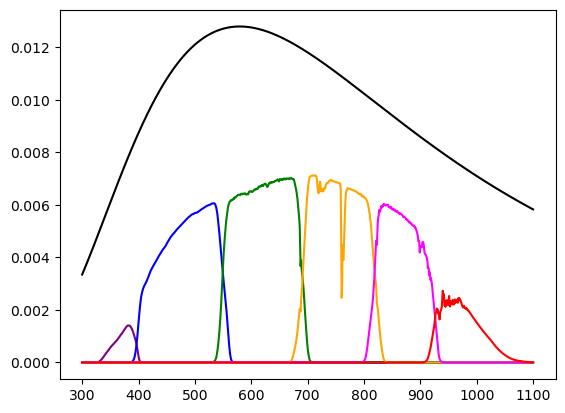

In [5]:
source_temperature = 5000 #K
reference_temperature = 4500 #K

wave = np.linspace(300, 1100, 1000)  # nm
BB_sed = BB(wave, source_temperature, scale = 1e-8)
ref_sed = BB(wave, reference_temperature, scale = 1e-8)

plt.plot(wave, BB_sed, 'k-')

BB_filtered = {}
ref_filtered = {}
for band in 'ugrizy':
    filtered_sed = apply_filter(wave, BB_sed, band)
    BB_filtered[band] = filtered_sed

    filtered_ref = apply_filter(wave, ref_sed, band)
    ref_filtered[band] = filtered_ref

    plt.plot(wave, BB_filtered[band], color = colors[band], label = band)



Text(0, 0.5, 'Second moment shift (arcsec$^2$)')

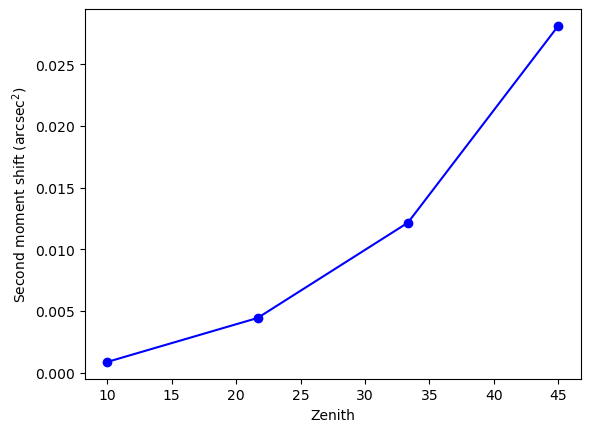

In [7]:
zeniths = np.linspace(10, 45, 4)

DCR1 = {} #first relative moment shifts (mean)
DCR2 = {} #second moment shifts (variance)

for band in 'ugrizy':
    DCR1[band] = np.array([])
    DCR2[band] = np.array([])

pressure=69.328
temperature=293.15
H2O_pressure=1.067

for zenith in zeniths:
    refraction_angles, filtered_refracted_data = apply_DCR(wave, BB_filtered, zenith, pressure, temperature, H2O_pressure)
    R_mean, R_stdev = weighted_avg_and_std(refraction_angles, filtered_refracted_data) #arcsec


    refraction_angles, filtered_refracted_data_ref = apply_DCR(wave, ref_filtered, zenith, pressure, temperature, H2O_pressure)
    R_mean_ref, R_stdev_ref = weighted_avg_and_std(refraction_angles, filtered_refracted_data_ref) #arcsec


    for band in 'ugrizy':
        DCR1[band] = np.append(DCR1[band], R_mean[band] - R_mean_ref[band])
        DCR2[band] = np.append(DCR2[band], (R_stdev[band])**2)


plt.plot(zeniths, DCR2['g'], 'b-o', label = 'g')
plt.xlabel('Zenith')
plt.ylabel('Second moment shift (arcsec$^2$)')

1.1512601791080939


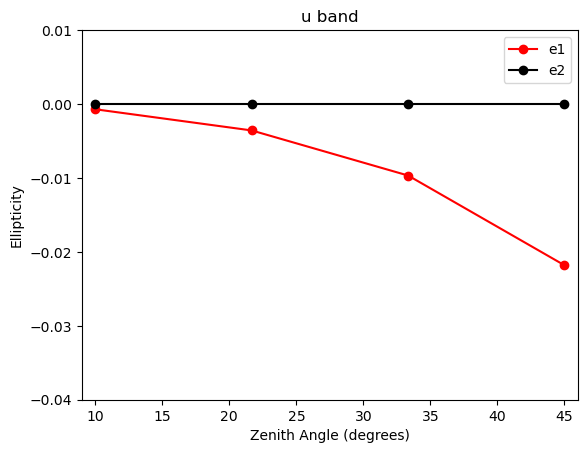

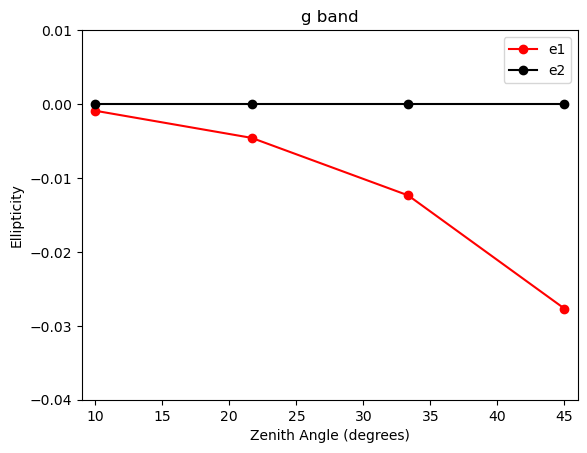

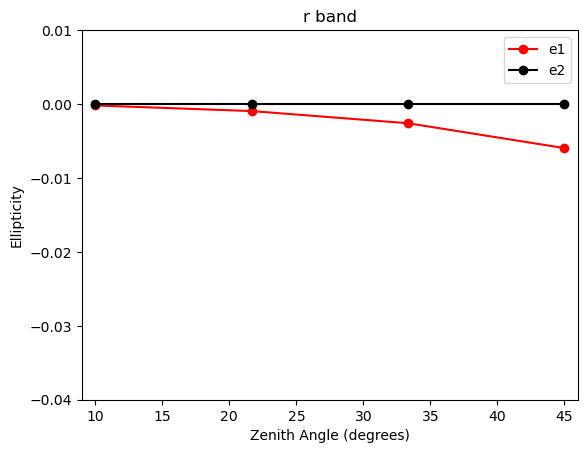

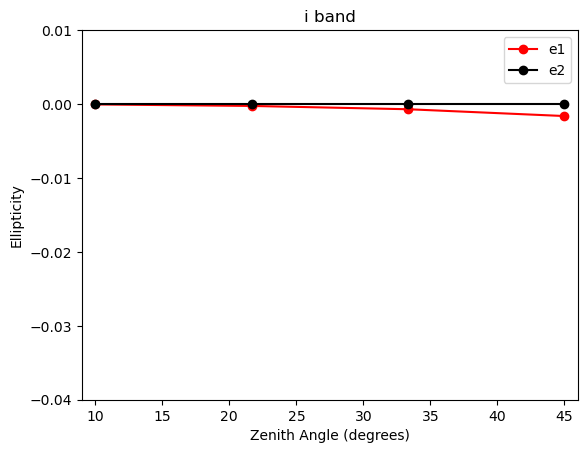

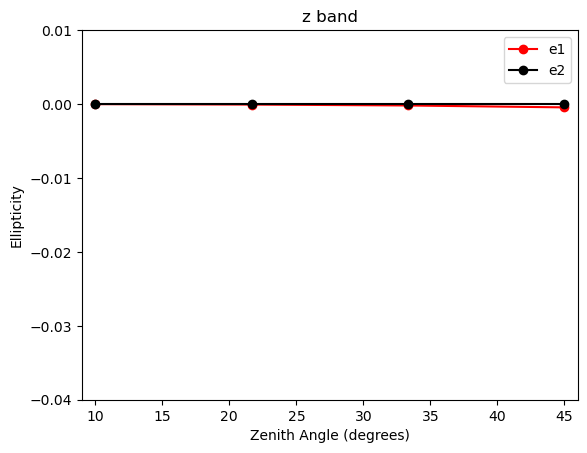

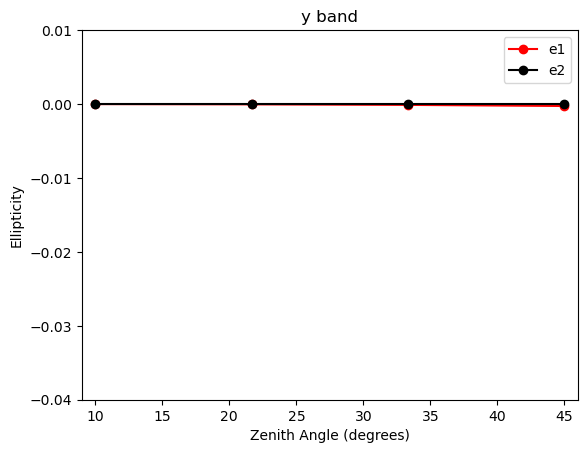

In [8]:
shape_xx = 6 * (0.2**2) #arcsec^2
shape_yy = 6 * (0.2**2) #arcsec^2
shape_xy = 0.0 * (0.2**2) #arcsec^2

print(np.sqrt(shape_xx)*2.35)

for band in 'ugrizy':
    Ixx = np.ones(len(DCR2[band])) * shape_xx
    Iyy = np.ones(len(DCR2[band])) * shape_yy + DCR2[band]
    Ixy = np.ones(len(DCR2[band])) * shape_xy

    e1 = (Ixx - Iyy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))
    e2 = (2 * Ixy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))

    plt.plot(zeniths, e1, 'r-o', label = 'e1')
    plt.plot(zeniths, e2, 'k-o', label = 'e2')
    plt.xlabel('Zenith Angle (degrees)')
    plt.ylabel(f'Ellipticity')
    plt.title(f'{band} band')
    plt.ylim(-0.04, 0.01)
    plt.xlim(9, 46)
    plt.legend()
    plt.show()
    plt.close()


In [ ]:
# create function to generate these quickly

def BB_dcr(source_temperature, reference_temperature, zeniths, shape_xx, shape_yy, shape_xy, plot = False, noise = None):

    wave = np.linspace(300, 1100, 1000)  # nm
    BB_sed = BB(wave, source_temperature, scale = 1e-8)
    ref_sed = BB(wave, reference_temperature, scale = 1e-8)

    BB_filtered = {}
    ref_filtered = {}
    for band in 'ugrizy':
        filtered_sed = apply_filter(wave, BB_sed, band)
        BB_filtered[band] = filtered_sed

        filtered_ref = apply_filter(wave, ref_sed, band)
        ref_filtered[band] = filtered_ref

    
    DCR1 = {} #first relative moment shifts (mean)
    DCR2 = {} #second moment shifts (variance)

    for band in 'ugrizy':
        DCR1[band] = np.array([])
        DCR2[band] = np.array([])

    pressure=69.328
    temperature=293.15
    H2O_pressure=1.067

    for zenith in zeniths:
        refraction_angles, filtered_refracted_data = apply_DCR(wave, BB_filtered, zenith, pressure, temperature, H2O_pressure)
        R_mean, R_stdev = weighted_avg_and_std(refraction_angles, filtered_refracted_data) #arcsec

        refraction_angles, filtered_refracted_data_ref = apply_DCR(wave, ref_filtered, zenith, pressure, temperature, H2O_pressure)
        R_mean_ref, R_stdev_ref = weighted_avg_and_std(refraction_angles, filtered_refracted_data_ref) #arcsec

        for band in 'ugrizy':
            DCR1[band] = np.append(DCR1[band], R_mean[band] - R_mean_ref[band])
            DCR2[band] = np.append(DCR2[band], (R_stdev[band])**2)

    e1 = {}
    e2 = {}

    if plot:
        fig, ax = plt.subplots(3, 2, figsize = (12,10), sharey = True)
        
    for i, band in enumerate('ugrizy'):
        Ixx = np.ones(len(DCR2[band])) * shape_xx
        Iyy = np.ones(len(DCR2[band])) * shape_yy + DCR2[band]
        Ixy = np.ones(len(DCR2[band])) * shape_xy

        e1[band] = (Ixx - Iyy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))
        e2[band] = (2 * Ixy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))

        if plot:
            ax[i//2, i%2].plot(zeniths, e1[band], 'r-o', label = f'e1 {band}')
            ax[i//2, i%2].plot(zeniths, e2[band], 'k-o', label = f'e2 {band}')
            ax[i//2, i%2].legend()

    return DCR1, DCR2, e1, e2

# zeniths = np.linspace(10, 45, 10)
# scrap = BB_dcr(7000, 4500, zeniths, shape_xx, shape_yy, shape_xy, plot = True)

Text(0, 0.5, 'Ellipticity e1')

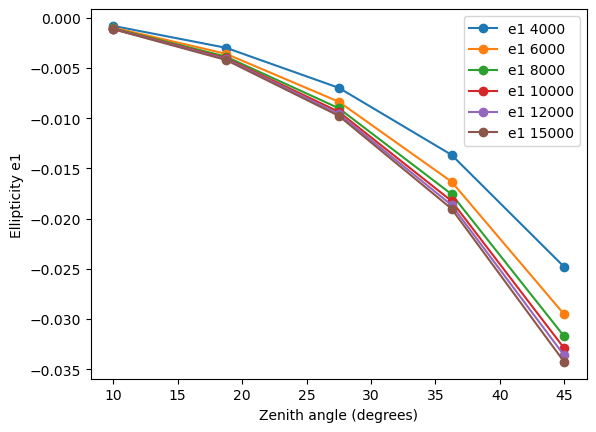

In [ ]:
source_temperatures = [4000, 6000, 8000, 10000, 12000, 15000]
zeniths = np.linspace(10, 45, 5)

# fig, ax = plt.subplots(3, 2, figsize = (12,10), sharey = True)

for source_temperature in source_temperatures:
    DCR1, DCR2, e1, e2 = BB_dcr(source_temperature, 4500, zeniths, shape_xx, shape_yy, shape_xy, plot = False)

    plt.plot(zeniths, e1['g'], '-o', label = f'e1 {source_temperature}')
    # for i, band in enumerate('ugrizy'):
    #     ax[i//2, i%2].plot(zeniths, e1[band], '-o', label = f'e1 {source_temperature}')
    #     ax[i//2, i%2].plot(zeniths, e2[band], 'k-o', label = f'e2 {source_temperature}')
    #     ax[i//2, i%2].set_title(f'Band {band}')
    #     ax[i//2, i%2].legend()

# plt.legend()
plt.xlabel('Zenith angle (degrees)')
plt.ylabel('Ellipticity e1')